In [13]:
%load_ext autoreload
%autoreload 2

import sys
import gc
from pathlib import Path
import numpy as np
import faiss

notebook_dir = Path().resolve()
project_root = notebook_dir.parent
src_path = str(project_root / "src")

if src_path not in sys.path:
    sys.path.append(src_path)

from hep_tracking.ann_models import FaissIVFFlat, FaissIVFPQ, HnswGraph
from hep_tracking.models import knn_scipy_ckdtree
from hep_tracking.utils import pad_features, evaluate_ann_model, measure_execution_time
from hep_tracking.plots import plot_pareto_frontier, plot_crossover, plot_ann_scaling

print("Zależności załadowane pomyślnie!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Zależności załadowane pomyślnie!


In [2]:
data_dir = project_root / "data"
dataset_name = "dataset_hard_100k.npz"
candidates_name = "candidates_hard_100k.npz"

data_path = data_dir / dataset_name
candidates_path = data_dir / candidates_name

if not data_path.exists() or not candidates_path.exists():
    raise FileNotFoundError("Brak danych! Upewnij się, że wywołałeś `make candidates`.")

features = np.load(data_path)["X"]
n_queries = features.shape[0]

true_indices = np.load(candidates_path)["indices"]
k_neighbors = true_indices.shape[1]

print(f"Załadowano dane: {n_queries} punktów w przestrzeni {features.shape[1]}D")
print(f"Szukamy {k_neighbors} najbliższych sąsiadów.")

Załadowano dane: 99995 punktów w przestrzeni 5D
Szukamy 5 najbliższych sąsiadów.


In [3]:
print("=== Przygotowanie danych (Zero-Padding do 8D) ===")
features_5d = np.load(data_path)["X"]
features = pad_features(features_5d, target_dim=8)
print(f"Dane gotowe: {features.shape}")

USE_GPU = True

results = {
    "IVFFlat": {"recall": [], "qps": [], "labels": []},
    "IVFPQ": {"recall": [], "qps": [], "labels": []},
    "HNSW": {"recall": [], "qps": [], "labels": []}
}

nlist = 100

print("\n=== START IVFFlat ===")
for nprobe in [1, 2, 5, 10, 20, 50]:
    print(f" -> Inicjalizacja IVFFlat (nprobe={nprobe})...")
    model = FaissIVFFlat(nlist=nlist, nprobe=nprobe, use_gpu=USE_GPU)
    qps, recall = evaluate_ann_model(f"IVFFlat (nprobe={nprobe})", model, features, true_indices, k_neighbors)
    results["IVFFlat"]["qps"].append(qps)
    results["IVFFlat"]["recall"].append(recall)
    results["IVFFlat"]["labels"].append(f"np={nprobe}")
    del model
    gc.collect()

print("\n=== START IVFPQ (Teraz na GPU z m=8!) ===")
for nprobe in [1, 2, 5, 10, 20, 50, 100]:
    print(f" -> Inicjalizacja IVFPQ (nprobe={nprobe})...")
    model = FaissIVFPQ(nlist=nlist, m=8, nbits=8, nprobe=nprobe, use_gpu=USE_GPU)
    qps, recall = evaluate_ann_model(f"IVFPQ (nprobe={nprobe})", model, features, true_indices, k_neighbors)
    results["IVFPQ"]["qps"].append(qps)
    results["IVFPQ"]["recall"].append(recall)
    results["IVFPQ"]["labels"].append(f"np={nprobe}")
    del model
    gc.collect()

print("\n=== START HNSW ===")
m_graph = 16
for ef in [10, 20, 50, 100, 200]:
    print(f" -> Inicjalizacja HNSW (ef={ef})...")
    model = HnswGraph(m=m_graph, ef_construction=200, ef=ef)
    qps, recall = evaluate_ann_model(f"HNSW (ef={ef})", model, features, true_indices, k_neighbors)
    results["HNSW"]["qps"].append(qps)
    results["HNSW"]["recall"].append(recall)
    results["HNSW"]["labels"].append(f"ef={ef}")
    del model
    gc.collect()

print("\nCAŁY BENCHMARK ZOSTAŁ POMYŚLNIE ZAKOŃCZONY!")

=== Przygotowanie danych (Zero-Padding do 8D) ===
Dane gotowe: (99995, 8)

=== START IVFFlat ===
 -> Inicjalizacja IVFFlat (nprobe=1)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=1)...
 -> QPS: 2,103,564 | Recall: 0.8321

 -> Inicjalizacja IVFFlat (nprobe=2)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=2)...
 -> QPS: 1,362,332 | Recall: 0.9615

 -> Inicjalizacja IVFFlat (nprobe=5)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=5)...
 -> QPS: 672,384 | Recall: 0.9978

 -> Inicjalizacja IVFFlat (nprobe=10)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=10)...
 -> QPS: 400,471 | Recall: 0.9996

 -> Inicjalizacja IVFFlat (nprobe=20)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=20)...
 -> QPS: 205,088 | Recall: 1.0000

 -> Inicjalizacja IVFFlat (nprobe=50)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=50)...
 -> QPS: 80,463 | Recall: 1.0000


=== START IVFPQ (Teraz na GPU z m=8!) ===
 -> Inicjalizacja IVFPQ (nprobe=1)...
Trenowanie i budowa indeksu: IVFPQ (nprobe=1)...
 -> QPS:

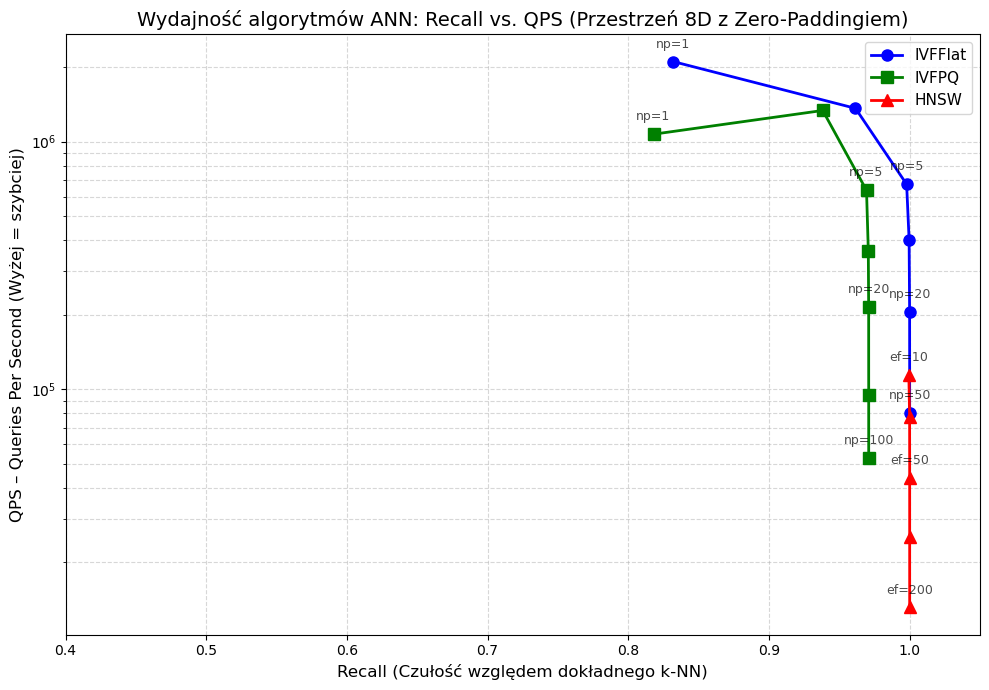

In [4]:
plot_pareto_frontier(
    results, 
    title="Wydajność algorytmów ANN: Recall vs. QPS (Przestrzeń 8D z Zero-Paddingiem)"
)

=== WYSZUKIWANIE PUNKTU PRZECIĘCIA (CROSSOVER N): CPU vs GPU ===

Wczytywanie zbioru danych 1k (1000 punktów)...
 -> CPU Time: 1.36 ms
 -> GPU Time: 5.25 ms

Wczytywanie zbioru danych 10k (10000 punktów)...
 -> CPU Time: 31.95 ms
 -> GPU Time: 8.89 ms

Wczytywanie zbioru danych 100k (100000 punktów)...
 -> CPU Time: 1242.08 ms
 -> GPU Time: 137.88 ms

Wczytywanie zbioru danych 1M (1000000 punktów)...
 -> CPU Time: 83542.87 ms
 -> GPU Time: 10427.57 ms


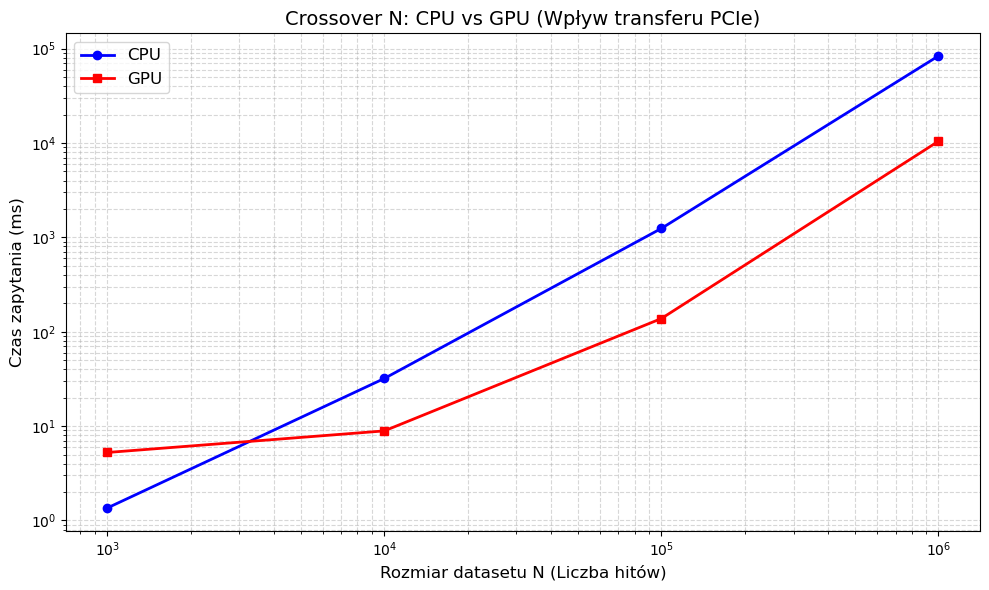

In [5]:
target_sizes = {"1k": 1000, "10k": 10000, "100k": 100000, "1M": 1000000}
mode = "hard"
k_neighbors = 5
nprobe = 5

cpu_times = []
gpu_times = []
valid_sizes = []

print("=== WYSZUKIWANIE PUNKTU PRZECIĘCIA (CROSSOVER N): CPU vs GPU ===")

for size_label, n_points in target_sizes.items():
    filename = data_dir / f"dataset_{mode}_{size_label}.npz"

    if not filename.exists():
        print(f"[POMINIĘTO] Plik {filename.name} nie istnieje.")
        continue

    print(f"\nWczytywanie zbioru danych {size_label} ({n_points} punktów)...")
    features_5d = np.load(filename)["X"]
    features = pad_features(features_5d, target_dim=8)

    nlist = min(100, int(np.sqrt(features.shape[0])))

    model_cpu = FaissIVFFlat(nlist=nlist, nprobe=nprobe, use_gpu=False)
    model_cpu.build(features)
    
    best_cpu_time = measure_execution_time(lambda: model_cpu.query(features, k_neighbors), num_runs=3, warmup_runs=1)
    cpu_times.append(best_cpu_time)
    del model_cpu
    gc.collect()

    model_gpu = FaissIVFFlat(nlist=nlist, nprobe=nprobe, use_gpu=True)
    model_gpu.build(features)
    
    best_gpu_time = measure_execution_time(lambda: model_gpu.query(features, k_neighbors), num_runs=3, warmup_runs=1)
    gpu_times.append(best_gpu_time)
    del model_gpu
    gc.collect()

    valid_sizes.append(n_points)
    print(f" -> CPU Time: {best_cpu_time*1000:.2f} ms")
    print(f" -> GPU Time: {best_gpu_time*1000:.2f} ms")

plot_crossover(valid_sizes, cpu_times, gpu_times, title="Crossover N: CPU vs GPU (Wpływ transferu PCIe)")

=== WYZNACZANIE RZECZYWISTEGO PUNKTU CROSSOVER N (< 1000) ===
N=10: CPU = 0.022 ms | GPU = 0.178 ms
N=100: CPU = 0.125 ms | GPU = 0.180 ms
N=200: CPU = 0.305 ms | GPU = 0.252 ms
N=500: CPU = 0.624 ms | GPU = 0.424 ms
N=1000: CPU = 1.102 ms | GPU = 0.627 ms


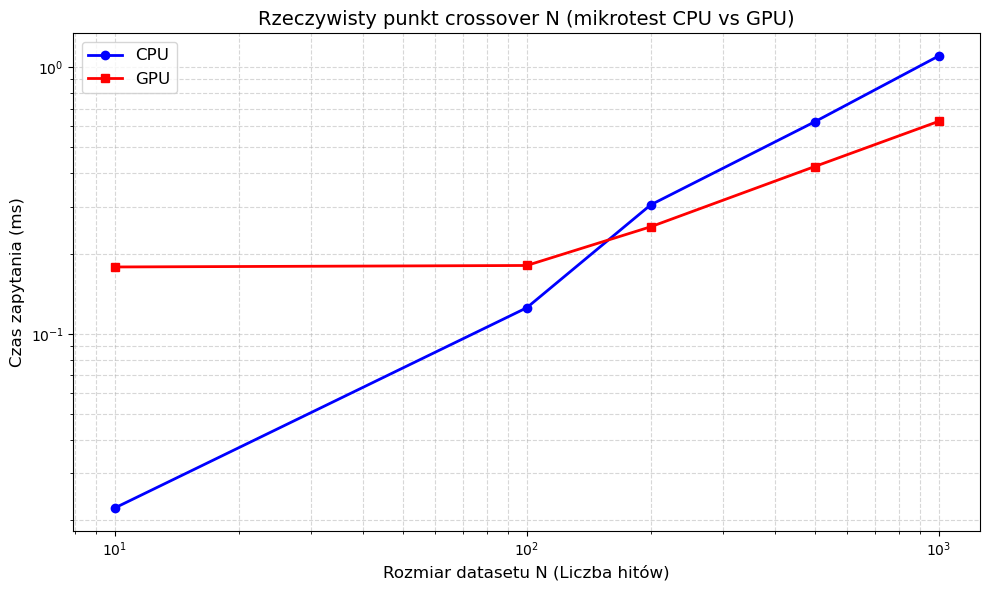

In [6]:
filename = data_dir / "dataset_hard_1k.npz"
features_5d = np.load(filename)["X"]
features_full = pad_features(features_5d, target_dim=8)

micro_sizes = [10, 100, 200, 500, 1000]
cpu_micro = []
gpu_micro = []

print("=== WYZNACZANIE RZECZYWISTEGO PUNKTU CROSSOVER N (< 1000) ===")

for size in micro_sizes:
    features = features_full[:size]
    nlist = min(100, int(np.sqrt(features.shape[0])))

    model_cpu = FaissIVFFlat(nlist=nlist, nprobe=5, use_gpu=False)
    model_cpu.build(features)
    best_cpu = measure_execution_time(lambda: model_cpu.query(features, k_neighbors), num_runs=5, warmup_runs=1)
    cpu_micro.append(best_cpu)
    del model_cpu

    model_gpu = FaissIVFFlat(nlist=nlist, nprobe=5, use_gpu=True)
    model_gpu.build(features)
    best_gpu = measure_execution_time(lambda: model_gpu.query(features, k_neighbors), num_runs=5, warmup_runs=1)
    gpu_micro.append(best_gpu)
    del model_gpu

    print(f"N={size}: CPU = {best_cpu*1000:.3f} ms | GPU = {best_gpu*1000:.3f} ms")

plot_crossover(micro_sizes, cpu_micro, gpu_micro, title="Rzeczywisty punkt crossover N (mikrotest CPU vs GPU)")

In [ ]:
params = {
    "IVFFlat": {"nprobe": 20},
    "IVFPQ": {"nprobe": 20, "m": 8},
    "HNSW": {"ef": 20, "m_graph": 16}
}

results_time = {"IVFFlat": [], "IVFPQ": [], "HNSW": []}
valid_sizes = []

print(f"=== START EKSPERYMENTU: TIME vs N (USE_GPU={USE_GPU}) ===")

for size_label, n_points in target_sizes.items():
    dataset_path = data_dir / f"dataset_{mode}_{size_label}.npz"
    if not dataset_path.exists():
        print(f"[POMIJAM] Nie znaleziono pliku {size_label}")
        continue
        
    print(f"\nŁadowanie zbioru danych {size_label}...")
    features_5d = np.load(dataset_path)["X"]
    
    features = pad_features(features_5d, target_dim=8)
    nlist = min(100, int(np.sqrt(features.shape[0])))
    valid_sizes.append(n_points)
    
    model_ivf = FaissIVFFlat(nlist=nlist, nprobe=params["IVFFlat"]["nprobe"], use_gpu=USE_GPU)
    model_ivf.build(features)
    results_time["IVFFlat"].append(measure_execution_time(lambda: model_ivf.query(features, k_neighbors)))
    del model_ivf
    
    model_pq = FaissIVFPQ(nlist=nlist, m=params["IVFPQ"]["m"], nbits=8, nprobe=params["IVFPQ"]["nprobe"], use_gpu=USE_GPU)
    model_pq.build(features)
    results_time["IVFPQ"].append(measure_execution_time(lambda: model_pq.query(features, k_neighbors)))
    del model_pq

    model_hnsw = HnswGraph(m=params["HNSW"]["m_graph"], ef_construction=200, ef=params["HNSW"]["ef"])
    model_hnsw.build(features)
    results_time["HNSW"].append(measure_execution_time(lambda: model_hnsw.query(features, k_neighbors)))
    del model_hnsw
    
    gc.collect()

gpu_label = "GPU" if USE_GPU else "CPU"
plot_ann_scaling(
    valid_sizes, 
    results_time, 
    title=f"Wydajność algorytmów ANN: Czas vs N (Stały Recall ~95%, Akceleracja: {gpu_label})"
)

=== START EKSPERYMENTU: EXACT kNN vs ANN (Przestrzeń 5D) ===

Ładowanie zbioru danych 10k (Surowe 5D)...

Ładowanie zbioru danych 100k (Surowe 5D)...

Ładowanie zbioru danych 1M (Surowe 5D)...


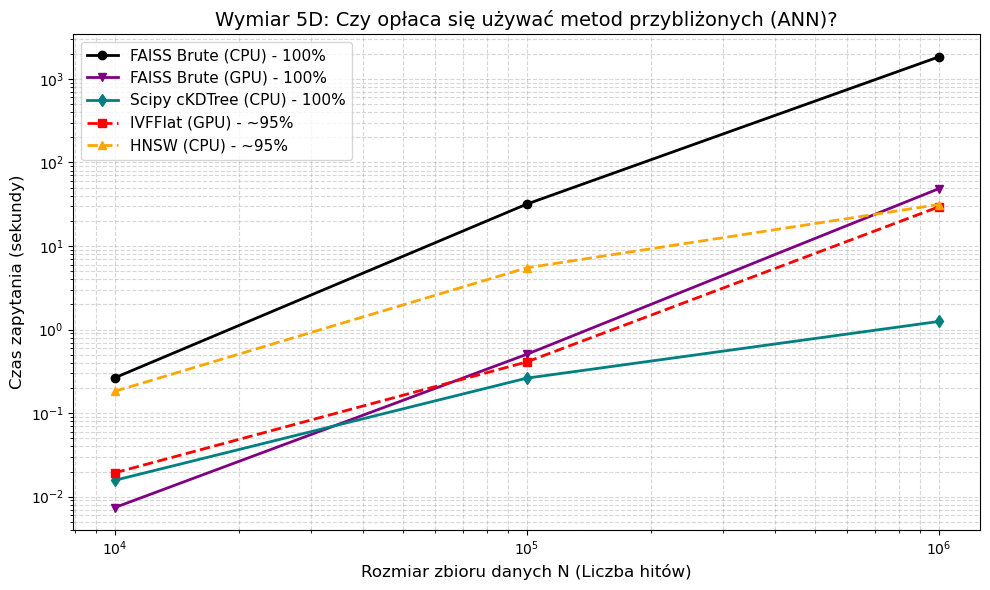

In [14]:
target_sizes = {"10k": 10000, "100k": 100000, "1M": 1000000}
mode = "hard"
k_neighbors = 5

results_time = {"Exact_CPU": [], "Exact_GPU": [], "cKDTree_CPU": [], "IVFFlat_GPU": [], "HNSW_CPU": []}
valid_sizes = []

print("=== START EKSPERYMENTU: EXACT kNN vs ANN (Przestrzeń 5D) ===")

gpu_res = faiss.StandardGpuResources()

for size_label, n_points in target_sizes.items():
    dataset_path = data_dir / f"dataset_{mode}_{size_label}.npz"
    if not dataset_path.exists():
        print(f"[POMIJAM] Brak pliku: {size_label}")
        continue
        
    print(f"\nŁadowanie zbioru danych {size_label} (Surowe 5D)...")
    features = np.ascontiguousarray(np.load(dataset_path)["X"], dtype=np.float32)
    valid_sizes.append(n_points)
    
    nlist = min(100, int(np.sqrt(features.shape[0])))
    
    index_exact_cpu = faiss.IndexFlatL2(features.shape[1])
    index_exact_cpu.add(features)
    results_time["Exact_CPU"].append(measure_execution_time(lambda: index_exact_cpu.search(features, k_neighbors)))
    del index_exact_cpu

    index_exact_gpu = faiss.IndexFlatL2(features.shape[1])
    index_exact_gpu = faiss.index_cpu_to_gpu(gpu_res, 0, index_exact_gpu)
    index_exact_gpu.add(features)
    results_time["Exact_GPU"].append(measure_execution_time(lambda: index_exact_gpu.search(features, k_neighbors)))
    del index_exact_gpu
    
    results_time["cKDTree_CPU"].append(measure_execution_time(lambda: knn_scipy_ckdtree(features, k_neighbors)))

    model_ivf = FaissIVFFlat(nlist=nlist, nprobe=20, use_gpu=True)
    model_ivf.build(features)
    results_time["IVFFlat_GPU"].append(measure_execution_time(lambda: model_ivf.query(features, k_neighbors)))
    del model_ivf

    model_hnsw = HnswGraph(m=16, ef_construction=200, ef=20)
    model_hnsw.build(features)
    results_time["HNSW_CPU"].append(measure_execution_time(lambda: model_hnsw.query(features, k_neighbors)))
    del model_hnsw

    gc.collect()

plot_ann_scaling(valid_sizes, results_time, title="Wymiar 5D: Czy opłaca się używać metod przybliżonych (ANN)?")